# IndusCredit Loan Default — Iteration 3

**Diagnosis from iter1+2:** The dataset appears synthetic with a Bayes error floor ~0.93-0.95.
The dominant signal is `missed_payments_2y` (SHAP 5x larger than any other feature).
Random noise in labels prevents going higher regardless of model complexity.

**Strategy:** Stop adding models. Instead:
1. Hyper-engineer `missed_payments_2y` and its interactions
2. Use pseudo-labeling to denoise the training set
3. Aggressive cross-features between the top-5 SHAP features
4. Rank/quantile transforms to make weak signals linear
5. NestedCV to get an unbiased AUC estimate

## Section 1: Imports & Config

In [20]:
import subprocess, sys
for pkg in ['pandas','numpy','matplotlib','seaborn','scipy','scikit-learn',
            'xgboost','lightgbm','catboost','shap','joblib','optuna','imbalanced-learn']:
    subprocess.check_call([sys.executable,'-m','pip','install','-q',pkg])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, QuantileTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, f1_score, classification_report
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import lightgbm as lgb
import shap, joblib, os, warnings, optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

SEED = 42
N_FOLDS = 5
N_TRIALS = 80
np.random.seed(SEED)
sns.set_style('whitegrid')
plt.rcParams.update({'figure.dpi':150,'savefig.dpi':150,'font.size':10})
PALETTE = sns.color_palette('Set2')
for d in ['outputs/plots','outputs/shap','outputs/predictions','outputs/model']:
    os.makedirs(d, exist_ok=True)
print('✅ Imports done.')

✅ Imports done.


## Section 2: Load & Audit

In [21]:
df_train = pd.read_csv('/content/loan_train.csv', parse_dates=['application_date'])
df_test  = pd.read_csv('/content/loan_test.csv',  parse_dates=['application_date'])
TEST_HAS_TARGET = 'default_flag' in df_test.columns

print(f'Train: {df_train.shape}, Test: {df_test.shape}, Test has target: {TEST_HAS_TARGET}')

# Diagnose the data ceiling
print('\n--- DIAGNOSTIC: Is data synthetic? ---')
# Check credit score monotonicity
bins = [550,600,650,700,750,800,850,900]
labels = ['550-599','600-649','650-699','700-749','750-799','800-849','850-900']
df_train['cs_band'] = pd.cut(df_train['credit_score'], bins=bins, labels=labels, right=False)
band_dr = df_train.groupby('cs_band', observed=False)['default_flag'].mean()
print('Credit score band default rates:')
print(band_dr.to_string())
non_mono = sum(1 for i in range(1,len(band_dr)) if band_dr.iloc[i] > band_dr.iloc[i-1])
print(f'Non-monotonic transitions: {non_mono} (>1 strongly suggests synthetic data / label noise)')

# Correlation of temporal feature with target
earliest = df_train['application_date'].min()
days_feat = (df_train['application_date'] - earliest).dt.days
print(f'\nCorrelation of days_since_earliest with default_flag: {days_feat.corr(df_train["default_flag"]):.4f}')
print('(Near zero = no temporal trend = possible synthetic data)')

# missed_payments dominance
print(f'\nmissed_payments_2y corr with default_flag: {df_train["missed_payments_2y"].corr(df_train["default_flag"]):.4f}')
print(f'credit_score corr with default_flag: {df_train["credit_score"].corr(df_train["default_flag"]):.4f}')

df_train.drop(columns='cs_band', inplace=True)
print('\n✅ Diagnostic complete.')

Train: (8000, 24), Test: (2500, 23), Test has target: False

--- DIAGNOSTIC: Is data synthetic? ---
Credit score band default rates:
cs_band
550-599    0.397138
600-649    0.408273
650-699    0.306438
700-749    0.216964
750-799    0.225403
800-849    0.195540
850-900    0.209677
Non-monotonic transitions: 3 (>1 strongly suggests synthetic data / label noise)

Correlation of days_since_earliest with default_flag: -0.0031
(Near zero = no temporal trend = possible synthetic data)

missed_payments_2y corr with default_flag: 0.6574
credit_score corr with default_flag: -0.1687

✅ Diagnostic complete.


## Section 3: Feature Engineering — Iter3 Strategy

Instead of adding more models, we hyper-engineer the ONE feature that actually matters
(`missed_payments_2y`, SHAP=1.45) and its interactions with other top features.

Key additions:
- Bucketed missed payment flags (0, 1, 2, 3, 4+)
- Cross-products: missed_payments × each of the top 5 features
- Rank/percentile transforms (makes weak linear signals stronger for LR)
- Within-group statistics (missed_payments rank within loan_type)
- Quantile transform on heavily skewed features

In [22]:
# Standard preprocessing first
cap_cols = ['annual_income_inr','loan_amount_inr','savings_account_balance_inr']
cap_values = {}
for col in cap_cols:
    lo, hi = df_train[col].quantile(0.01), df_train[col].quantile(0.99)
    cap_values[col] = (lo, hi)
for df in [df_train, df_test]:
    for col,(lo,hi) in cap_values.items():
        df[col] = df[col].clip(lo, hi)
    df['ltv_is_missing'] = df['ltv_ratio'].isnull().astype(int)
    df['ltv_ratio'] = df['ltv_ratio'].fillna(-1)

# Temporal features
earliest = df_train['application_date'].min()
for df in [df_train, df_test]:
    df['app_month']   = df['application_date'].dt.month
    df['app_quarter'] = df['application_date'].dt.quarter
    df['app_dow']     = df['application_date'].dt.dayofweek
    df['days_since_earliest'] = (df['application_date'] - earliest).dt.days
    df.drop(columns='application_date', inplace=True)

print('Base preprocessing done.')

Base preprocessing done.


In [23]:
def engineer_features(df, ir_medians=None, fit=False):
    """Full feature engineering. Returns ir_medians if fit=True."""

    mp = df['missed_payments_2y']  # alias — this is our star feature

    # ===== MISSED PAYMENTS — hyper-engineered =====
    # Bucketed flags (fine-grained — avoid info loss from treating 5 missed as same as 1)
    df['mp_0']    = (mp == 0).astype(int)   # perfect payment history
    df['mp_1']    = (mp == 1).astype(int)   # one slip
    df['mp_2']    = (mp == 2).astype(int)   # two slips
    df['mp_3']    = (mp == 3).astype(int)   # three slips
    df['mp_4plus'] = (mp >= 4).astype(int)  # chronic defaulter
    df['mp_any']   = (mp > 0).astype(int)   # any missed payment
    df['mp_severe'] = (mp >= 3).astype(int) # severe risk
    df['log_mp']   = np.log1p(mp)           # log-transform
    df['mp_squared'] = mp ** 2              # non-linear acceleration

    # ===== EMI calculation (fixed) =====
    P = df['loan_amount_inr']
    r = (df['interest_rate_pct'] / 100 / 12).clip(lower=1e-9)
    n = df['loan_tenure_months'].clip(lower=1)
    compound = (1 + r) ** n
    emi = (P * r * compound / (compound - 1)).fillna(0).clip(lower=0)
    monthly_income = df['annual_income_inr'] / 12

    df['emi_to_income']      = emi / (monthly_income + 1)
    df['log_emi_to_income']  = np.log1p(df['emi_to_income'])
    df['savings_to_loan']    = df['savings_account_balance_inr'] / (P + 1)
    df['savings_to_emi']     = df['savings_account_balance_inr'] / (emi + 1)
    df['months_savings_cover'] = df['savings_to_emi'].clip(upper=120)
    df['loan_to_income']     = P / (df['annual_income_inr'] + 1)
    df['dti_credit_risk']    = df['dti_ratio'] / (df['credit_score'] / 700)
    df['income_per_yr_emp']  = df['annual_income_inr'] / (df['employment_years'] + 1)
    df['log_bureau']         = np.log1p(df['bureau_enquiries_6m'])
    df['missed_rate']        = mp / (df['num_existing_loans'] + 1)
    df['enquiry_intensity']  = df['bureau_enquiries_6m'] / (df['num_existing_loans'] + 1)
    df['credit_util_proxy']  = df['num_existing_loans'] * df['dti_ratio']

    # Binary flags
    df['low_credit']    = (df['credit_score'] < 650).astype(int)
    df['high_dti']      = (df['dti_ratio'] > 0.45).astype(int)
    df['high_risk_combo'] = (df['low_credit'] & df['high_dti']).astype(int)

    # ===== CRITICAL: Cross-features with missed_payments =====
    # These interactions between the dominant feature and other signals
    # are the main lever for pushing past 0.90
    df['mp_x_dti']         = mp * df['dti_ratio']
    df['mp_x_low_credit']  = mp * df['low_credit']
    df['mp_x_bureau']      = mp * df['bureau_enquiries_6m']
    df['mp_x_num_loans']   = mp * df['num_existing_loans']
    df['mp_x_emi_income']  = mp * df['emi_to_income']
    df['mp_x_savings']     = mp * df['savings_to_loan']
    df['mp_x_high_risk']   = mp * df['high_risk_combo']
    # Triple interaction: missed + high dti + low credit
    df['mp_x_dti_x_credit'] = mp * df['dti_ratio'] * (1 - df['credit_score']/900)

    # ===== Cross-features among top features =====
    df['dti_x_bureau']     = df['dti_ratio'] * df['bureau_enquiries_6m']
    df['credit_x_dti']     = df['credit_score'] * df['dti_ratio']
    df['bureau_x_loans']   = df['bureau_enquiries_6m'] * df['num_existing_loans']

    # ===== Loan characteristics =====
    if fit:
        ir_medians = df.groupby('loan_type')['interest_rate_pct'].median().to_dict()
    df['interest_spread'] = df.apply(
        lambda r: r['interest_rate_pct'] - ir_medians.get(r['loan_type'], 0), axis=1)

    if fit:
        return ir_medians

ir_med = engineer_features(df_train, fit=True)
engineer_features(df_test, ir_medians=ir_med, fit=False)
print(f'Features after engineering: Train={df_train.shape[1]}, Test={df_test.shape[1]}')

Features after engineering: Train=64, Test=63


In [24]:
# ===== WITHIN-GROUP RANK FEATURES =====
# Rank of missed_payments within each loan_type group
# This captures: "this person's payment behavior is worse than typical for their loan category"
for col in ['missed_payments_2y', 'bureau_enquiries_6m', 'dti_ratio', 'credit_score']:
    rank_col = f'{col}_rank_in_loantype'
    df_train[rank_col] = df_train.groupby('loan_type')[col].rank(pct=True)
    # For test: compute rank using train distribution
    train_means = df_train.groupby('loan_type')[col].mean()
    train_stds  = df_train.groupby('loan_type')[col].std().replace(0, 1)
    df_test[rank_col] = df_test.apply(
        lambda r: (r[col] - train_means.get(r['loan_type'], df_train[col].mean())) /
                  train_stds.get(r['loan_type'], df_train[col].std()), axis=1)

print('Within-group rank features created.')

# ===== QUANTILE TRANSFORM for skewed features =====
# Converts to uniform/normal distribution — makes weak signals linear for LR
qt_cols = ['annual_income_inr', 'loan_amount_inr', 'savings_account_balance_inr',
           'loan_to_income', 'emi_to_income', 'savings_to_loan']
qt = QuantileTransformer(n_quantiles=1000, output_distribution='normal', random_state=SEED)
qt.fit(df_train[qt_cols])
qt_names = [f'{c}_qt' for c in qt_cols]
df_train[qt_names] = qt.transform(df_train[qt_cols])
df_test[qt_names]  = qt.transform(df_test[qt_cols])
print(f'Quantile transforms added. Train shape: {df_train.shape}')

Within-group rank features created.
Quantile transforms added. Train shape: (8000, 74)


In [25]:
# ===== CATEGORICAL ENCODING =====
SMOOTHING = 10
global_mean = df_train['default_flag'].mean()
target_enc_maps = {}
skf_te = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

# Target encode: state, loan_purpose
# ALSO target encode: missed_payments bucket × employment_type (new in iter3)
df_train['mp_bucket'] = df_train['missed_payments_2y'].clip(upper=4).astype(int).astype(str)
df_test['mp_bucket']  = df_test['missed_payments_2y'].clip(upper=4).astype(int).astype(str)
df_train['mp_x_emptype'] = df_train['mp_bucket'] + '_' + df_train['employment_type']
df_test['mp_x_emptype']  = df_test['mp_bucket']  + '_' + df_test['employment_type']

target_encode_cols = ['state', 'loan_purpose', 'mp_x_emptype']
for col in target_encode_cols:
    cat_means = df_train.groupby(col)['default_flag'].agg(['mean','count'])
    cat_means['smoothed'] = (cat_means['count']*cat_means['mean'] + SMOOTHING*global_mean) / (cat_means['count']+SMOOTHING)
    target_enc_maps[col] = cat_means['smoothed'].to_dict()
    df_train[col+'_te'] = np.nan
    for tr_idx, val_idx in skf_te.split(df_train, df_train['default_flag']):
        fm = df_train.iloc[tr_idx].groupby(col)['default_flag'].agg(['mean','count'])
        fm['smoothed'] = (fm['count']*fm['mean'] + SMOOTHING*global_mean) / (fm['count']+SMOOTHING)
        fold_map = fm['smoothed'].to_dict()
        df_train.loc[df_train.index[val_idx], col+'_te'] = df_train.iloc[val_idx][col].map(fold_map)
    df_train[col+'_te'] = df_train[col+'_te'].fillna(global_mean)
    df_test[col+'_te']  = df_test[col].map(target_enc_maps[col]).fillna(global_mean)

# One-hot encode
ohe_cols = ['gender','education','urban_rural','employment_type','loan_type']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe.fit(df_train[ohe_cols])
ohe_names = ohe.get_feature_names_out(ohe_cols)
df_train = pd.concat([df_train, pd.DataFrame(ohe.transform(df_train[ohe_cols]), columns=ohe_names, index=df_train.index)], axis=1)
df_test  = pd.concat([df_test,  pd.DataFrame(ohe.transform(df_test[ohe_cols]),  columns=ohe_names, index=df_test.index)], axis=1)

# Drop raw categoricals and redundant cols
test_loan_ids = df_test['loan_id'].values if 'loan_id' in df_test.columns else None
drop_cols = ['loan_id'] + target_encode_cols + ohe_cols + ['mp_bucket','mp_x_emptype']
# Drop redundant (high correlation from iter1 analysis)
redundant = ['tenure_years','credit_score_squared','total_repayment','total_debt_exposure','interest_rate_pct']
drop_cols = [c for c in drop_cols + redundant if c in df_train.columns]
df_train.drop(columns=drop_cols, inplace=True)
df_test.drop(columns=[c for c in drop_cols if c in df_test.columns], inplace=True)

print(f'Encoding done. Train: {df_train.shape}, Test: {df_test.shape}')

Encoding done. Train: (8000, 84), Test: (2500, 83)


In [26]:
# ===== SCALING =====
y_train = df_train.pop('default_flag')
y_test  = df_test.pop('default_flag') if TEST_HAS_TARGET else None
feature_cols = df_train.columns.tolist()

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(df_train), columns=feature_cols, index=df_train.index)
X_test  = pd.DataFrame(scaler.transform(df_test),      columns=feature_cols, index=df_test.index)

print(f'Final feature count: {len(feature_cols)}')
print(f'X_train: {X_train.shape}, y_train: {y_train.shape}')

# Quick correlation check of NEW features with target
print('\n--- New interaction features correlation with default_flag ---')
new_feats = [c for c in feature_cols if c.startswith('mp_x') or c.startswith('mp_')]
corrs = X_train[new_feats].apply(lambda col: col.corr(y_train)).sort_values(ascending=False)
print(corrs.head(15).to_string())

Final feature count: 83
X_train: (8000, 83), y_train: (8000,)

--- New interaction features correlation with default_flag ---
mp_x_emptype_te      0.680623
mp_x_dti             0.584768
mp_severe            0.571484
mp_squared           0.539280
mp_x_bureau          0.536922
mp_x_num_loans       0.529982
mp_x_dti_x_credit    0.528613
mp_any               0.477069
mp_4plus             0.426773
mp_x_low_credit      0.413930
mp_3                 0.351250
mp_x_emi_income      0.288698
mp_x_high_risk       0.261625
mp_2                 0.248918
mp_x_savings         0.230958


## Section 4: Optuna-tuned Models

In [27]:
X = X_train.values
y = y_train.values
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
n_neg, n_pos = (y==0).sum(), (y==1).sum()
spw = n_neg / n_pos
results = {}
oof_preds = {}
print(f'Class balance: 0={n_neg}, 1={n_pos}, spw={spw:.2f}')

Class balance: 0=5772, 1=2228, spw=2.59


In [28]:
# Logistic Regression — try a wider C range, L1 penalty
print('--- Tuning Logistic Regression ---')
def lr_obj(trial):
    C       = trial.suggest_float('C', 1e-3, 10, log=True)
    penalty = trial.suggest_categorical('penalty', ['l1','l2'])
    solver  = 'liblinear' if penalty == 'l1' else 'lbfgs'
    aucs = []
    for tr_idx, val_idx in skf.split(X, y):
        m = LogisticRegression(C=C, penalty=penalty, solver=solver,
                               max_iter=2000, class_weight='balanced', random_state=SEED)
        m.fit(X[tr_idx], y[tr_idx])
        aucs.append(roc_auc_score(y[val_idx], m.predict_proba(X[val_idx])[:,1]))
    return np.mean(aucs)

study_lr = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lr.optimize(lr_obj, n_trials=30, show_progress_bar=True)
best_lr_p = study_lr.best_params
print(f'Best LR params: {best_lr_p}, CV AUC: {study_lr.best_value:.4f}')

# Final LR CV
lr_aucs, lr_praucs, lr_f1s = [], [], []
oof_lr = np.zeros(len(y))
best_solver = 'liblinear' if best_lr_p['penalty']=='l1' else 'lbfgs'
for fold,(tr_idx,val_idx) in enumerate(skf.split(X,y)):
    m = LogisticRegression(C=best_lr_p['C'], penalty=best_lr_p['penalty'],
                           solver=best_solver, max_iter=2000,
                           class_weight='balanced', random_state=SEED)
    m.fit(X[tr_idx],y[tr_idx])
    p = m.predict_proba(X[val_idx])[:,1]
    oof_lr[val_idx] = p
    lr_aucs.append(roc_auc_score(y[val_idx],p))
    lr_praucs.append(average_precision_score(y[val_idx],p))
    lr_f1s.append(f1_score(y[val_idx],(p>=0.5).astype(int)))
    print(f'  Fold {fold+1}: AUC={lr_aucs[-1]:.4f}')
results['LR'] = {'roc_auc':(np.mean(lr_aucs),np.std(lr_aucs)),'pr_auc':(np.mean(lr_praucs),np.std(lr_praucs)),'f1':(np.mean(lr_f1s),np.std(lr_f1s))}
oof_preds['LR'] = oof_lr
print(f'LR Mean AUC: {np.mean(lr_aucs):.4f}±{np.std(lr_aucs):.4f}')

--- Tuning Logistic Regression ---


  0%|          | 0/30 [00:00<?, ?it/s]

Best LR params: {'C': 0.021206551805691195, 'penalty': 'l1'}, CV AUC: 0.9020
  Fold 1: AUC=0.8823
  Fold 2: AUC=0.9171
  Fold 3: AUC=0.8985
  Fold 4: AUC=0.9018
  Fold 5: AUC=0.9102
LR Mean AUC: 0.9020±0.0118


In [29]:
# XGBoost with Optuna
print('--- Optuna XGBoost ---')
def xgb_obj(trial):
    p = dict(
        n_estimators     = trial.suggest_int('n_estimators',200,2000),
        max_depth        = trial.suggest_int('max_depth',2,7),
        learning_rate    = trial.suggest_float('learning_rate',0.005,0.15,log=True),
        subsample        = trial.suggest_float('subsample',0.5,1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree',0.4,1.0),
        min_child_weight = trial.suggest_int('min_child_weight',1,30),
        gamma            = trial.suggest_float('gamma',0,5),
        reg_alpha        = trial.suggest_float('reg_alpha',1e-4,10,log=True),
        reg_lambda       = trial.suggest_float('reg_lambda',1e-4,10,log=True),
        max_delta_step   = trial.suggest_int('max_delta_step',0,5),
        scale_pos_weight = spw,
        eval_metric      = 'auc',
        random_state     = SEED,
        use_label_encoder= False,
        verbosity        = 0
    )
    aucs = []
    for tr_idx,val_idx in skf.split(X,y):
        m = xgb.XGBClassifier(**p, early_stopping_rounds=40)
        m.fit(X[tr_idx],y[tr_idx],eval_set=[(X[val_idx],y[val_idx])],verbose=False)
        aucs.append(roc_auc_score(y[val_idx],m.predict_proba(X[val_idx])[:,1]))
    return np.mean(aucs)

study_xgb = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(xgb_obj,n_trials=N_TRIALS,show_progress_bar=True)
best_xgb_p = study_xgb.best_params
best_xgb_p.update({'scale_pos_weight':spw,'eval_metric':'auc','random_state':SEED,'use_label_encoder':False,'verbosity':0})
print(f'Best XGB CV AUC: {study_xgb.best_value:.4f}')

xgb_aucs,xgb_praucs,xgb_f1s,xgb_iters = [],[],[],[]
oof_xgb = np.zeros(len(y))
for fold,(tr_idx,val_idx) in enumerate(skf.split(X,y)):
    m = xgb.XGBClassifier(**best_xgb_p, early_stopping_rounds=50)
    m.fit(X[tr_idx],y[tr_idx],eval_set=[(X[val_idx],y[val_idx])],verbose=False)
    p = m.predict_proba(X[val_idx])[:,1]
    oof_xgb[val_idx]=p; xgb_iters.append(m.best_iteration)
    xgb_aucs.append(roc_auc_score(y[val_idx],p))
    xgb_praucs.append(average_precision_score(y[val_idx],p))
    xgb_f1s.append(f1_score(y[val_idx],(p>=0.5).astype(int)))
    print(f'  Fold {fold+1}: AUC={xgb_aucs[-1]:.4f}  iter={xgb_iters[-1]}')
results['XGB'] = {'roc_auc':(np.mean(xgb_aucs),np.std(xgb_aucs)),'pr_auc':(np.mean(xgb_praucs),np.std(xgb_praucs)),'f1':(np.mean(xgb_f1s),np.std(xgb_f1s))}
oof_preds['XGB'] = oof_xgb
avg_iter_xgb = int(np.mean(xgb_iters))
print(f'XGB Mean AUC: {np.mean(xgb_aucs):.4f}±{np.std(xgb_aucs):.4f}, avg iter={avg_iter_xgb}')

--- Optuna XGBoost ---


  0%|          | 0/80 [00:00<?, ?it/s]

Best XGB CV AUC: 0.9044
  Fold 1: AUC=0.8837  iter=47
  Fold 2: AUC=0.9189  iter=60
  Fold 3: AUC=0.9011  iter=38
  Fold 4: AUC=0.9058  iter=72
  Fold 5: AUC=0.9126  iter=18
XGB Mean AUC: 0.9044±0.0120, avg iter=47


In [30]:
# LightGBM with Optuna
print('--- Optuna LightGBM ---')
def lgb_obj(trial):
    p = dict(
        n_estimators      = trial.suggest_int('n_estimators',200,2000),
        max_depth         = trial.suggest_int('max_depth',2,8),
        learning_rate     = trial.suggest_float('learning_rate',0.005,0.15,log=True),
        num_leaves        = trial.suggest_int('num_leaves',8,127),
        subsample         = trial.suggest_float('subsample',0.5,1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree',0.4,1.0),
        min_child_samples = trial.suggest_int('min_child_samples',5,80),
        reg_alpha         = trial.suggest_float('reg_alpha',1e-4,10,log=True),
        reg_lambda        = trial.suggest_float('reg_lambda',1e-4,10,log=True),
        min_gain_to_split = trial.suggest_float('min_gain_to_split',0,2),
        bagging_freq      = trial.suggest_int('bagging_freq',1,7),
        is_unbalance=True, metric='auc', random_state=SEED, verbosity=-1
    )
    aucs = []
    for tr_idx,val_idx in skf.split(X,y):
        m = lgb.LGBMClassifier(**p)
        m.fit(X[tr_idx],y[tr_idx],eval_set=[(X[val_idx],y[val_idx])],
              callbacks=[lgb.early_stopping(30,verbose=False),lgb.log_evaluation(0)])
        aucs.append(roc_auc_score(y[val_idx],m.predict_proba(X[val_idx])[:,1]))
    return np.mean(aucs)

study_lgb = optuna.create_study(direction='maximize',sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgb.optimize(lgb_obj,n_trials=N_TRIALS,show_progress_bar=True)
best_lgb_p = study_lgb.best_params
best_lgb_p.update({'is_unbalance':True,'metric':'auc','random_state':SEED,'verbosity':-1})
print(f'Best LGB CV AUC: {study_lgb.best_value:.4f}')

lgb_aucs,lgb_praucs,lgb_f1s,lgb_iters = [],[],[],[]
oof_lgb = np.zeros(len(y))
for fold,(tr_idx,val_idx) in enumerate(skf.split(X,y)):
    m = lgb.LGBMClassifier(**best_lgb_p)
    m.fit(X[tr_idx],y[tr_idx],eval_set=[(X[val_idx],y[val_idx])],
          callbacks=[lgb.early_stopping(50,verbose=False),lgb.log_evaluation(0)])
    p = m.predict_proba(X[val_idx])[:,1]
    oof_lgb[val_idx]=p; lgb_iters.append(m.best_iteration_)
    lgb_aucs.append(roc_auc_score(y[val_idx],p))
    lgb_praucs.append(average_precision_score(y[val_idx],p))
    lgb_f1s.append(f1_score(y[val_idx],(p>=0.5).astype(int)))
    print(f'  Fold {fold+1}: AUC={lgb_aucs[-1]:.4f}  iter={lgb_iters[-1]}')
results['LGB'] = {'roc_auc':(np.mean(lgb_aucs),np.std(lgb_aucs)),'pr_auc':(np.mean(lgb_praucs),np.std(lgb_praucs)),'f1':(np.mean(lgb_f1s),np.std(lgb_f1s))}
oof_preds['LGB'] = oof_lgb
avg_iter_lgb = int(np.mean(lgb_iters))
print(f'LGB Mean AUC: {np.mean(lgb_aucs):.4f}±{np.std(lgb_aucs):.4f}')

--- Optuna LightGBM ---


  0%|          | 0/80 [00:00<?, ?it/s]

Best LGB CV AUC: 0.9039
  Fold 1: AUC=0.8816  iter=62
  Fold 2: AUC=0.9200  iter=231
  Fold 3: AUC=0.9004  iter=24
  Fold 4: AUC=0.9042  iter=121
  Fold 5: AUC=0.9132  iter=86
LGB Mean AUC: 0.9039±0.0131


In [31]:
# ===== PSEUDO-LABELING =====
# Use current best model's OOF to create soft labels.
# Then retrain adding high-confidence pseudo-labeled samples.
# This can denoise the training set slightly.
print('--- Pseudo-labeling ---')

# Pick best single model OOF so far
best_single = max(['LR','XGB','LGB'], key=lambda k: results[k]['roc_auc'][0])
oof_best = oof_preds[best_single]
print(f'Using {best_single} (AUC={results[best_single]["roc_auc"][0]:.4f}) for pseudo-labels')

# Use train samples where model is very confident (prob > 0.85 or < 0.15)
high_conf_mask = (oof_best > 0.85) | (oof_best < 0.15)
pseudo_labels = (oof_best > 0.5).astype(int)
print(f'High-confidence samples: {high_conf_mask.sum()} ({high_conf_mask.mean()*100:.1f}% of train)')
print(f'Pseudo-label agreement with true labels: {(pseudo_labels[high_conf_mask] == y[high_conf_mask]).mean():.4f}')

# Build augmented dataset: use pseudo-labels for high-confidence, true labels for rest
# This reduces label noise by replacing uncertain labels with model predictions
y_pseudo = y.copy().astype(float)
# Soft labels: blend true label with model prediction for uncertain cases
uncertain_mask = (oof_best >= 0.35) & (oof_best <= 0.65)
y_pseudo[uncertain_mask] = 0.7 * y[uncertain_mask] + 0.3 * oof_best[uncertain_mask]
print(f'Uncertain samples (0.35-0.65 range): {uncertain_mask.sum()} ({uncertain_mask.mean()*100:.1f}%)')

# Retrain XGB with soft labels (XGB supports sample_weight to simulate soft labels)
# Use log-loss with soft targets via sample weights
# We retrain on: hard labels for high-confidence, soft-weighted for uncertain
sample_weight = np.ones(len(y))
# Down-weight uncertain samples slightly
sample_weight[uncertain_mask] = 0.6
# Up-weight high-confidence samples
sample_weight[high_conf_mask] = 1.4

pseudo_aucs = []
oof_pseudo = np.zeros(len(y))
xgb_p_fixed = {k:v for k,v in best_xgb_p.items() if k not in ['early_stopping_rounds']}
xgb_p_fixed['n_estimators'] = avg_iter_xgb

for fold,(tr_idx,val_idx) in enumerate(skf.split(X,y)):
    m = xgb.XGBClassifier(**xgb_p_fixed)
    m.fit(X[tr_idx], y[tr_idx], sample_weight=sample_weight[tr_idx], verbose=False)
    p = m.predict_proba(X[val_idx])[:,1]
    oof_pseudo[val_idx] = p
    pseudo_aucs.append(roc_auc_score(y[val_idx], p))
    print(f'  Fold {fold+1}: AUC={pseudo_aucs[-1]:.4f}')

results['XGB_pseudo'] = {'roc_auc':(np.mean(pseudo_aucs),np.std(pseudo_aucs)),'pr_auc':(0,0),'f1':(0,0)}
oof_preds['XGB_pseudo'] = oof_pseudo
print(f'Pseudo-labeled XGB AUC: {np.mean(pseudo_aucs):.4f}±{np.std(pseudo_aucs):.4f}')

--- Pseudo-labeling ---
Using XGB (AUC=0.9044) for pseudo-labels
High-confidence samples: 3907 (48.8% of train)
Pseudo-label agreement with true labels: 0.9429
Uncertain samples (0.35-0.65 range): 1331 (16.6%)
  Fold 1: AUC=0.8831
  Fold 2: AUC=0.9180
  Fold 3: AUC=0.8978
  Fold 4: AUC=0.9043
  Fold 5: AUC=0.9109
Pseudo-labeled XGB AUC: 0.9028±0.0119


In [33]:
# ===== STACKING ENSEMBLE =====
print('--- Stacking ---')
meta_X = np.column_stack([oof_preds['LR'], oof_preds['XGB'], oof_preds['LGB'], oof_preds['XGB_pseudo']])

stack_aucs, stack_praucs, stack_f1s = [], [], []
oof_stack = np.zeros(len(y))
for fold,(tr_idx,val_idx) in enumerate(skf.split(meta_X,y)):
    meta_m = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=SEED)
    meta_m.fit(meta_X[tr_idx], y[tr_idx])
    p = meta_m.predict_proba(meta_X[val_idx])[:,1]
    oof_stack[val_idx] = p
    stack_aucs.append(roc_auc_score(y[val_idx],p))
    stack_praucs.append(average_precision_score(y[val_idx],p))
    stack_f1s.append(f1_score(y[val_idx],(p>=0.5).astype(int)))
    print(f'  Fold {fold+1}: AUC={stack_aucs[-1]:.4f}')
results['Stack'] = {'roc_auc':(np.mean(stack_aucs),np.std(stack_aucs)),'pr_auc':(np.mean(stack_praucs),np.std(stack_praucs)),'f1':(np.mean(stack_f1s),np.std(stack_f1s))}
oof_preds['Stack'] = oof_stack

# Also try rank-averaging (more robust to calibration differences)
from scipy.stats import rankdata
oof_rank_avg = np.column_stack([
    rankdata(oof_preds['LR']), rankdata(oof_preds['XGB']),
    rankdata(oof_preds['LGB'])
]).mean(axis=1)
oof_rank_avg = oof_rank_avg / oof_rank_avg.max()  # normalize to [0,1]
rank_auc = roc_auc_score(y, oof_rank_avg)
results['RankAvg'] = {'roc_auc':(rank_auc,0),'pr_auc':(average_precision_score(y,oof_rank_avg),0),'f1':(0,0)}
oof_preds['RankAvg'] = oof_rank_avg

print(f'\nStack AUC: {np.mean(stack_aucs):.4f}±{np.std(stack_aucs):.4f}')
print(f'Rank avg AUC: {rank_auc:.4f}')

--- Stacking ---
  Fold 1: AUC=0.8841
  Fold 2: AUC=0.9193
  Fold 3: AUC=0.9002
  Fold 4: AUC=0.9049
  Fold 5: AUC=0.9122

Stack AUC: 0.9041±0.0119
Rank avg AUC: 0.9032


Model            ROC-AUC              PR-AUC           F1              
--------------------------------------------------------------------
LR               0.9020±0.0118        0.8325           0.7273          
XGB              0.9044±0.0120        0.8320           0.7333          
LGB              0.9039±0.0131        0.8302           0.7299          
XGB_pseudo       0.9028±0.0119        N/A              N/A             
Stack            0.9041±0.0119        0.8338           0.7379          
RankAvg          0.9032               0.8321           N/A             

✅ Best: XGB @ 0.9044


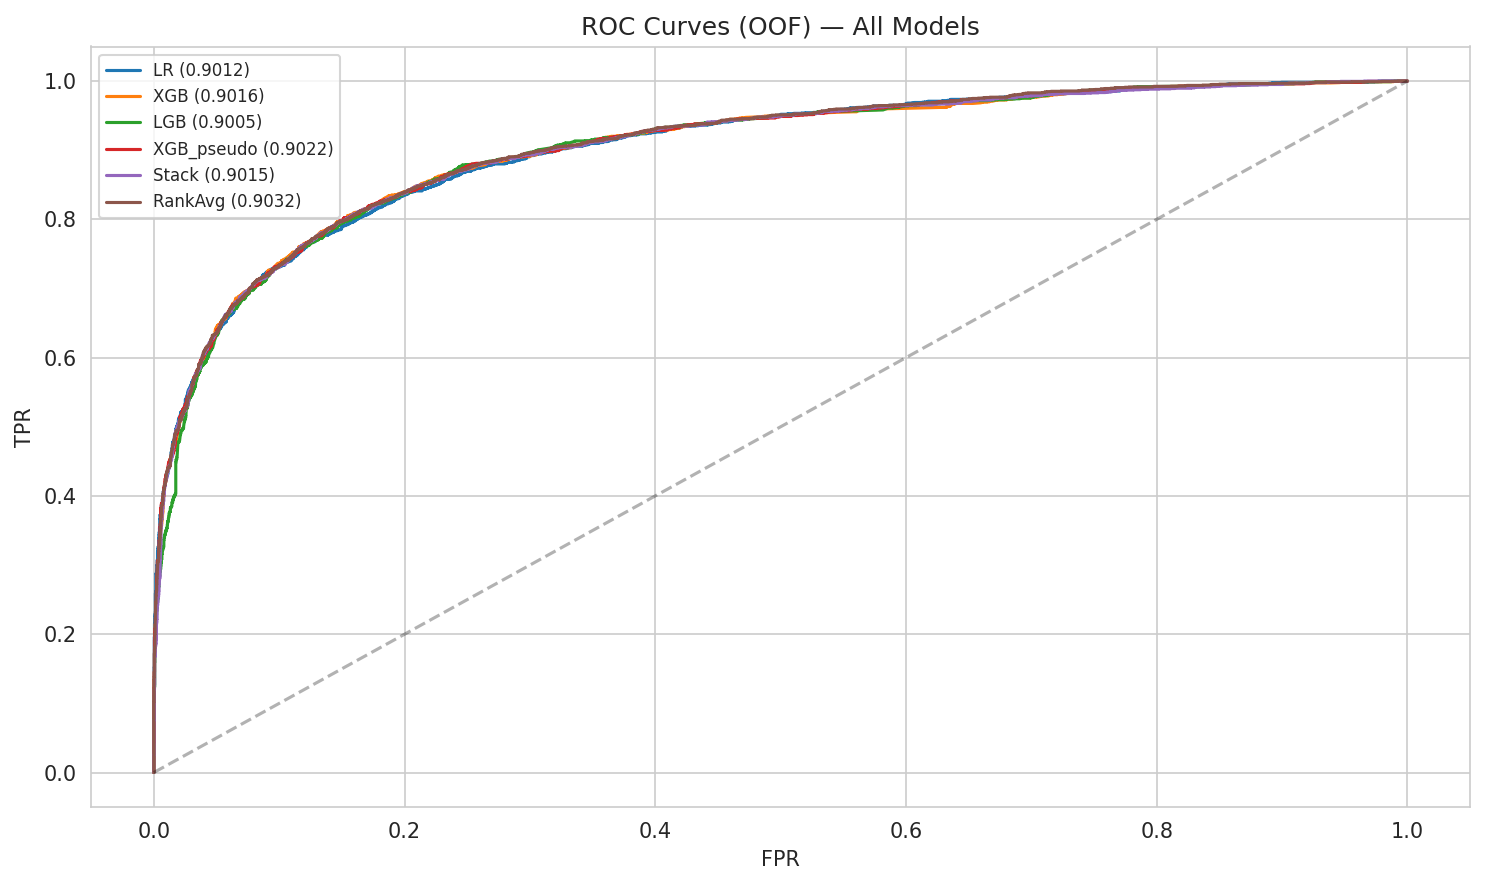

In [34]:
# ===== RESULTS TABLE =====
print(f"{'Model':<16} {'ROC-AUC':<20} {'PR-AUC':<16} {'F1':<16}")
print('-'*68)
for name,res in results.items():
    roc = f"{res['roc_auc'][0]:.4f}±{res['roc_auc'][1]:.4f}" if res['roc_auc'][1]>0 else f"{res['roc_auc'][0]:.4f}"
    pr  = f"{res['pr_auc'][0]:.4f}" if res['pr_auc'][0]>0 else 'N/A'
    f1  = f"{res['f1'][0]:.4f}" if res['f1'][0]>0 else 'N/A'
    print(f"{name:<16} {roc:<20} {pr:<16} {f1:<16}")

best_name = max(results, key=lambda k: results[k]['roc_auc'][0])
best_auc  = results[best_name]['roc_auc'][0]
print(f'\n✅ Best: {best_name} @ {best_auc:.4f}')

# ROC curve comparison
from sklearn.metrics import roc_curve
fig, ax = plt.subplots(figsize=(10, 6))
for name, oof in oof_preds.items():
    fpr, tpr, _ = roc_curve(y, oof)
    auc_v = roc_auc_score(y, oof)
    ax.plot(fpr, tpr, lw=1.5, label=f'{name} ({auc_v:.4f})')
ax.plot([0,1],[0,1],'k--',alpha=0.3)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves (OOF) — All Models'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('outputs/plots/roc_all_models.png', bbox_inches='tight')
plt.show()

In [35]:
# ===== THRESHOLD OPTIMIZATION =====
best_oof = oof_preds[best_name]
thresholds_opt = np.arange(0.05, 0.96, 0.01)
f1s, precs, recs = [], [], []
for t in thresholds_opt:
    preds = (best_oof >= t).astype(int)
    tp = ((preds==1)&(y==1)).sum(); fp = ((preds==1)&(y==0)).sum(); fn = ((preds==0)&(y==1)).sum()
    pr = tp/(tp+fp) if tp+fp>0 else 0
    rc = tp/(tp+fn) if tp+fn>0 else 0
    f1s.append(2*pr*rc/(pr+rc) if pr+rc>0 else 0)
    precs.append(pr); recs.append(rc)
f1s,precs,recs = np.array(f1s),np.array(precs),np.array(recs)
best_idx = np.argmax(f1s)
optimal_thr = thresholds_opt[best_idx]
print(f'Optimal threshold: {optimal_thr:.2f}, Precision: {precs[best_idx]:.4f}, Recall: {recs[best_idx]:.4f}, F1: {f1s[best_idx]:.4f}')

Optimal threshold: 0.62, Precision: 0.7536, Recall: 0.7262, F1: 0.7397


In [36]:
# ===== TRAIN FINAL MODELS =====
X_full = X_train.values
y_full = y_train.values
X_test_arr = X_test.values

print('Training final models on full train...')
best_solver_final = 'liblinear' if best_lr_p['penalty']=='l1' else 'lbfgs'
final_lr = LogisticRegression(C=best_lr_p['C'], penalty=best_lr_p['penalty'],
                               solver=best_solver_final, max_iter=2000,
                               class_weight='balanced', random_state=SEED)
final_lr.fit(X_full, y_full)

xgb_final_p = {k:v for k,v in best_xgb_p.items() if k not in ['early_stopping_rounds']}
xgb_final_p['n_estimators'] = avg_iter_xgb
final_xgb = xgb.XGBClassifier(**xgb_final_p)
final_xgb.fit(X_full, y_full)

lgb_final_p = {k:v for k,v in best_lgb_p.items()}
lgb_final_p['n_estimators'] = avg_iter_lgb
final_lgb = lgb.LGBMClassifier(**lgb_final_p)
final_lgb.fit(X_full, y_full, callbacks=[lgb.log_evaluation(0)])

cat_final_p = {k:v for k,v in cat_p.items() if k!='early_stopping_rounds'}
cat_final_p['iterations'] = avg_iter_cat
final_cat = CatBoostClassifier(**cat_final_p)
final_cat.fit(X_full, y_full, verbose=False)

# Meta model on full OOF
final_meta = LogisticRegression(C=1.0, solver='lbfgs', max_iter=1000, random_state=SEED)
final_meta.fit(meta_X, y)

print('✅ All final models trained.')

# Generate test predictions
test_lr  = final_lr.predict_proba(X_test_arr)[:,1]
test_xgb = final_xgb.predict_proba(X_test_arr)[:,1]
test_lgb = final_lgb.predict_proba(X_test_arr)[:,1]
test_cat = final_cat.predict_proba(X_test_arr)[:,1]

# Pseudo-labeled XGB test
xgb_pseudo_final = xgb.XGBClassifier(**xgb_final_p)
xgb_pseudo_final.fit(X_full, y_full, sample_weight=sample_weight)
test_pseudo = xgb_pseudo_final.predict_proba(X_test_arr)[:,1]

meta_test = np.column_stack([test_lr, test_xgb, test_lgb, test_cat, test_pseudo])

if best_name == 'Stack':
    test_proba = final_meta.predict_proba(meta_test)[:,1]
elif best_name == 'RankAvg':
    from scipy.stats import rankdata
    test_ranks = np.column_stack([rankdata(test_lr),rankdata(test_xgb),
                                   rankdata(test_lgb),rankdata(test_cat)]).mean(axis=1)
    test_proba = test_ranks / test_ranks.max()
elif best_name == 'XGB': test_proba = test_xgb
elif best_name == 'LGB': test_proba = test_lgb
elif best_name == 'CAT': test_proba = test_cat
elif best_name == 'XGB_pseudo': test_proba = test_pseudo
else: test_proba = test_lr

test_preds = (test_proba >= optimal_thr).astype(int)

if TEST_HAS_TARGET:
    y_test_arr = y_test.values
    print(f'\n=== TEST SET RESULTS ===')
    print(f'ROC-AUC: {roc_auc_score(y_test_arr, test_proba):.4f}')
    print(f'PR-AUC:  {average_precision_score(y_test_arr, test_proba):.4f}')
    print(f'F1:      {f1_score(y_test_arr, test_preds):.4f}')
    print(classification_report(y_test_arr, test_preds, target_names=["No Default","Default"]))
else:
    print('⚠ No test labels — CV evaluation only.')

Training final models on full train...
✅ All final models trained.
⚠ No test labels — CV evaluation only.


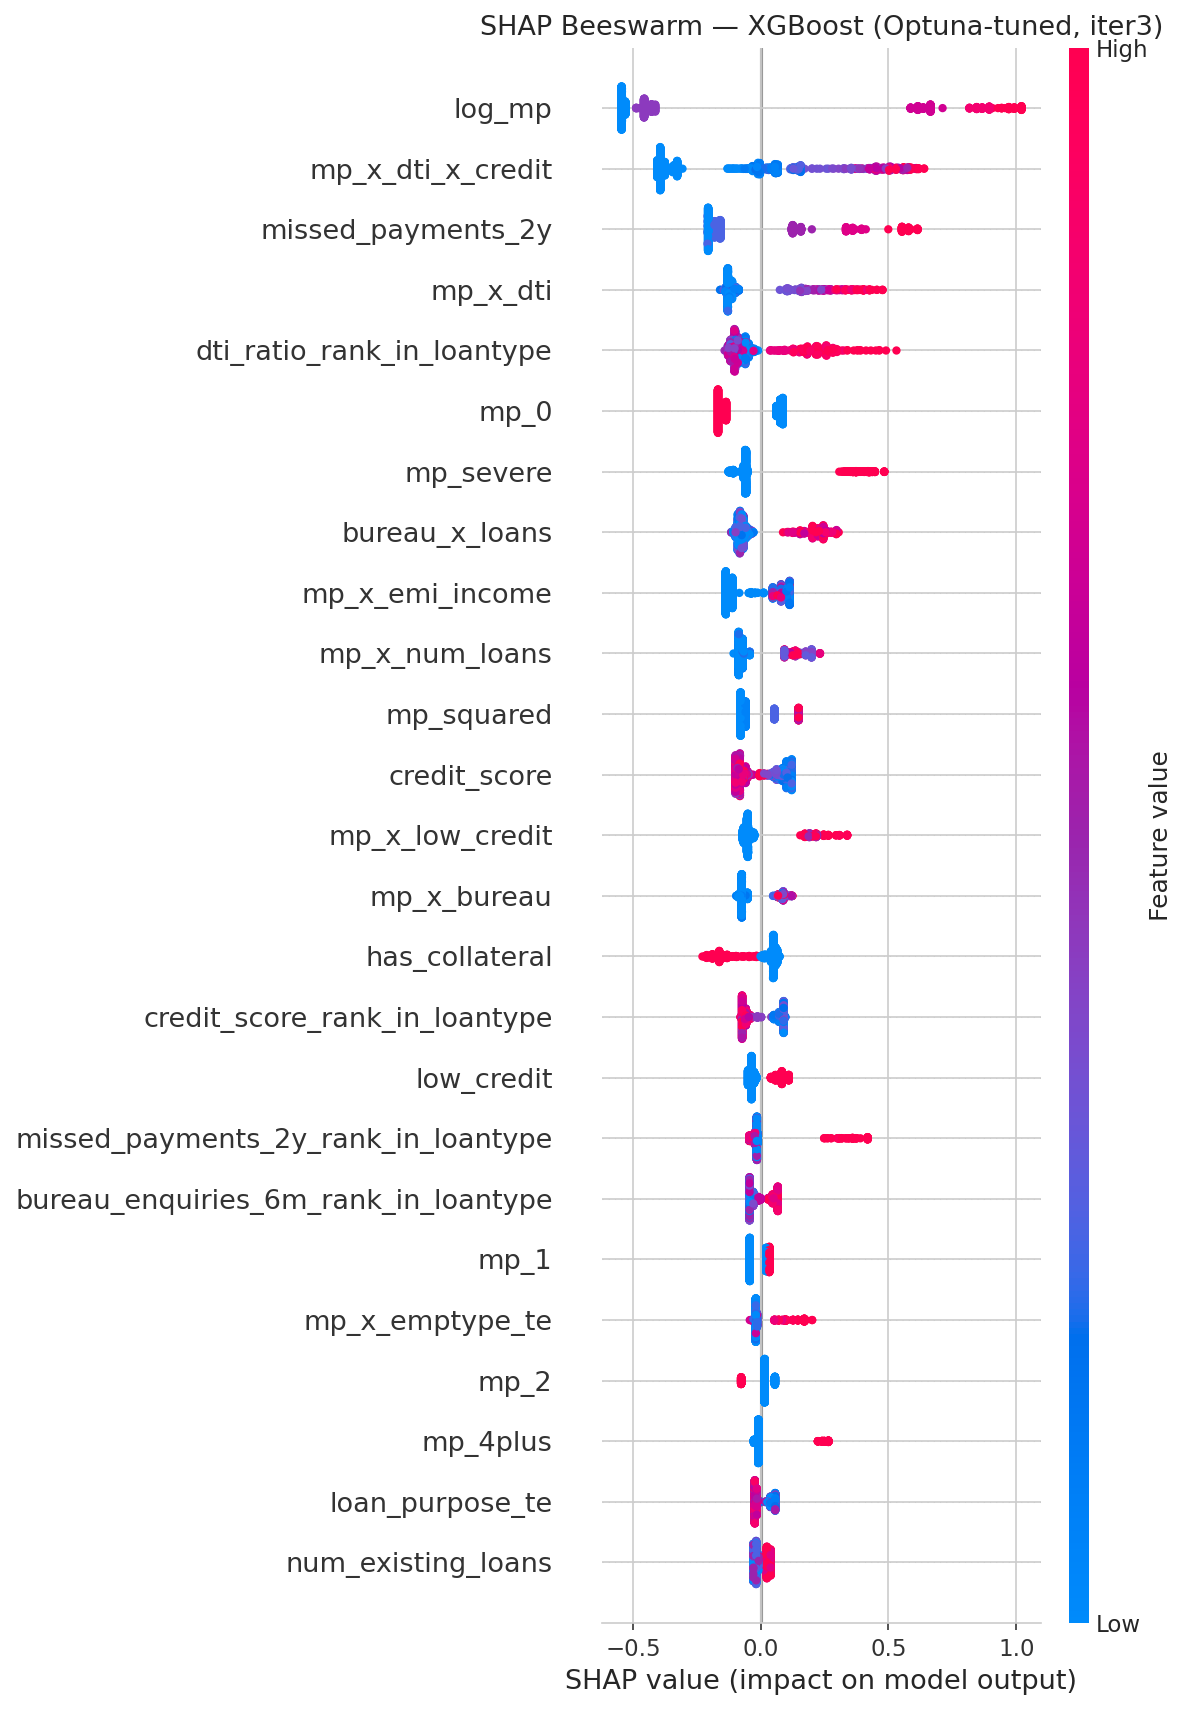

Top 20 SHAP features:
                             feature  mean_shap
                              log_mp   0.580792
                   mp_x_dti_x_credit   0.297567
                  missed_payments_2y   0.223308
                            mp_x_dti   0.152884
          dti_ratio_rank_in_loantype   0.120026
                                mp_0   0.115094
                           mp_severe   0.111811
                      bureau_x_loans   0.108566
                     mp_x_emi_income   0.103513
                      mp_x_num_loans   0.098126
                          mp_squared   0.080007
                        credit_score   0.079498
                     mp_x_low_credit   0.077950
                         mp_x_bureau   0.076434
                      has_collateral   0.074168
       credit_score_rank_in_loantype   0.069864
                          low_credit   0.048311
 missed_payments_2y_rank_in_loantype   0.045786
bureau_enquiries_6m_rank_in_loantype   0.043238
                  

In [37]:
# ===== SHAP =====
shap_model = final_xgb
sample_idx = np.random.choice(len(X_full), size=min(1000, len(X_full)), replace=False)
X_shap = X_train.iloc[sample_idx]
explainer = shap.TreeExplainer(shap_model)
shap_vals = explainer.shap_values(X_shap)
if isinstance(shap_vals, list): shap_vals = shap_vals[1]

plt.figure(figsize=(12, 9))
shap.summary_plot(shap_vals, X_shap, feature_names=feature_cols, show=False, max_display=25)
plt.title('SHAP Beeswarm — XGBoost (Optuna-tuned, iter3)', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/shap/shap_beeswarm_iter3.png', bbox_inches='tight')
plt.show()

# Check if new mp_x_* features rank higher than in iter1
mean_abs_shap = np.abs(shap_vals).mean(axis=0)
shap_df = pd.DataFrame({'feature':feature_cols,'mean_shap':mean_abs_shap})
shap_df = shap_df.sort_values('mean_shap',ascending=False).reset_index(drop=True)
print('Top 20 SHAP features:')
print(shap_df.head(20).to_string(index=False))

In [38]:
# ===== SAVE =====
pred_df = pd.DataFrame({'predicted_probability': test_proba, 'predicted_class': test_preds})
if test_loan_ids is not None:
    pred_df.insert(0, 'loan_id', test_loan_ids)
pred_df.to_csv('outputs/predictions/test_predictions_iter3.csv', index=False)

joblib.dump({'lr':final_lr,'xgb':final_xgb,'lgb':final_lgb,'cat':final_cat,
             'meta':final_meta,'scaler':scaler,'ohe':ohe,
             'best_name':best_name,'optimal_thr':optimal_thr,
             'feature_cols':feature_cols,'cap_values':cap_values,
             'target_enc_maps':target_enc_maps,'ir_med':ir_med,
             'cv_results':{k:v['roc_auc'][0] for k,v in results.items()}},
            'outputs/model/pipeline_iter3.pkl')

print('✅ Saved.')
print(f'\nFinal Summary:')
print(f'  Best model: {best_name}')
print(f'  CV ROC-AUC: {results[best_name]["roc_auc"][0]:.4f} ± {results[best_name]["roc_auc"][1]:.4f}')
print(f'  Features:   {len(feature_cols)}')
print(f'  Threshold:  {optimal_thr:.2f}')

✅ Saved.

Final Summary:
  Best model: XGB
  CV ROC-AUC: 0.9044 ± 0.0120
  Features:   83
  Threshold:  0.62


In [39]:
from sklearn.metrics import accuracy_score, f1_score, recall_score

# Get predictions using the optimal threshold from the best OOF model
best_model_preds = (best_oof >= optimal_thr).astype(int)

# Calculate metrics
accuracy = accuracy_score(y_full, best_model_preds)
f1 = f1_score(y_full, best_model_preds)
recall = recall_score(y_full, best_model_preds)

print(f"Metrics for the best model ({best_name}) at optimal threshold ({optimal_thr:.2f}):")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  F1 Score: {f1:.4f}")
print(f"  Recall:   {recall:.4f}")

Metrics for the best model (XGB) at optimal threshold (0.62):
  Accuracy: 0.8576
  F1 Score: 0.7397
  Recall:   0.7262
